# Notebook 02 - Red neuronal profunda (MLP)

En este notebook implementamos una red neuronal profunda completamente conectada (MLP) como modelo base para la clasificación de actividades humanas.

## 1. Importaciones y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


## 2. Carga de datos preprocesados

In [2]:
DATA_DIR = '../data/processed'

X_tr = np.load(os.path.join(DATA_DIR, 'X_tr.npy'))
X_val = np.load(os.path.join(DATA_DIR, 'X_val.npy'))
X_test = np.load(os.path.join(DATA_DIR, 'X_test.npy'))

y_tr = np.load(os.path.join(DATA_DIR, 'y_tr.npy'))
y_val = np.load(os.path.join(DATA_DIR, 'y_val.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

y_test_int = np.load(os.path.join(DATA_DIR, 'y_test_int.npy'))

nombres_clases = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

print('Datos cargados:')
print('  Train:', X_tr.shape)
print('  Validation:', X_val.shape)
print('  Test:', X_test.shape)

Datos cargados:
  Train: (5881, 561)
  Validation: (1471, 561)
  Test: (2947, 561)


## 3. Arquitectura del modelo MLP

Una red MLP (Multilayer Perceptron) es una red neuronal completamente conectada donde cada neurona de una capa está conectada con todas las neuronas de la capa siguiente. Es el modelo más básico de aprendizaje profundo.

Nuestra arquitectura:
- Capa de entrada: 561 características
- Capas ocultas con ReLU y Dropout para regularización
- Capa de salida: 6 neuronas con softmax (una por clase)

In [3]:
# Definición del modelo MLP
modelo_mlp = Sequential([
    # Primera capa oculta
    Dense(256, activation='relu', input_shape=(561,)),
    BatchNormalization(),
    Dropout(0.3),

    # Segunda capa oculta
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Tercera capa oculta
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Capa de salida
    Dense(6, activation='softmax')
])

modelo_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       143,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,950 (730.27 KB)

 Trainable params: 186,182 (727.27 KB)

 Non-trainable params: 768 (3.00 KB)

La arquitectura tiene 3 capas ocultas. Usamos:
- **ReLU**: función de activación que evita el problema del gradiente desvaneciente.
- **Dropout**: apaga aleatoriamente neuronas durante el entrenamiento para evitar overfitting.
- **BatchNormalization**: normaliza las activaciones para estabilizar el entrenamiento.
- **Softmax**: convierte las salidas en probabilidades que suman 1.

## 4. Compilación y entrenamiento

In [4]:
# Compilar el modelo
modelo_mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping para evitar overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Medir tiempo de entrenamiento
inicio = time.time()

historial = modelo_mlp.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

tiempo_entrenamiento = time.time() - inicio
print(f'\nTiempo de entrenamiento: {tiempo_entrenamiento:.2f} segundos')

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7713 - loss: 0.5847 - val_accuracy: 0.9375 - val_loss: 0.1808
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9194 - loss: 0.2101 - val_accuracy: 0.9524 - val_loss: 0.1017
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9505 - loss: 0.1370 - val_accuracy: 0.9708 - val_loss: 0.0753
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9585 - loss: 0.1126 - val_accuracy: 0.9674 - val_loss: 0.0781
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9590 - loss: 0.1060 - val_accuracy: 0.9585 - val_loss: 0.1007
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9663 - loss: 0.0884 - val_accuracy: 0.9646 - val_loss: 0.0916
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9701 - loss: 0.0800 - val_accuracy: 0.9714 - val_loss: 0.0657
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9728 - loss: 0.0755 - val_accuracy: 0.96

## 5. Curvas de aprendizaje

Las curvas de aprendizaje nos permiten observar cómo evoluciona la pérdida y la precisión durante el entrenamiento. Si la pérdida de validación aumenta mientras la de entrenamiento disminuye, es señal de overfitting.

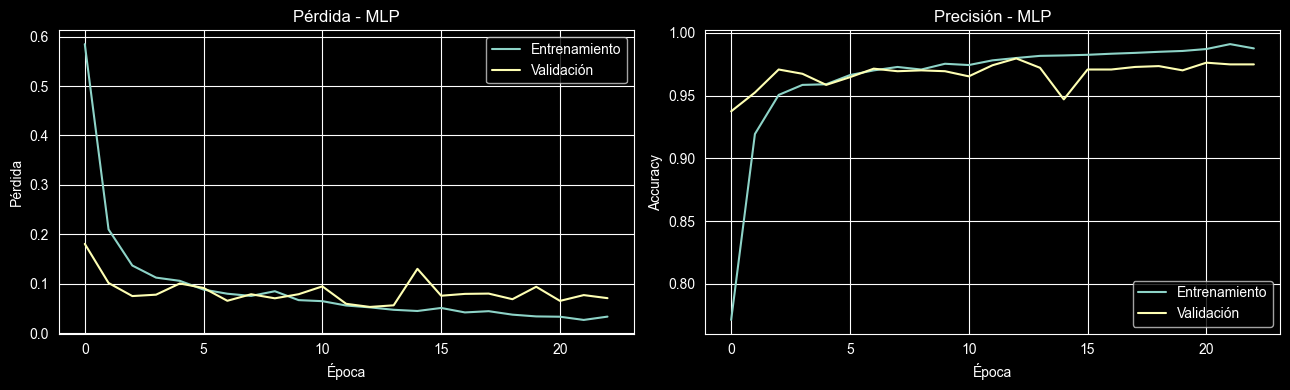

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pérdida
axes[0].plot(historial.history['loss'], label='Entrenamiento')
axes[0].plot(historial.history['val_loss'], label='Validación')
axes[0].set_title('Pérdida - MLP')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()

# Precisión
axes[1].plot(historial.history['accuracy'], label='Entrenamiento')
axes[1].plot(historial.history['val_accuracy'], label='Validación')
axes[1].set_title('Precisión - MLP')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/curvas_mlp.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Evaluación en el conjunto de prueba

In [6]:
# Predicciones
y_pred_prob = modelo_mlp.predict(X_test)
y_pred_int = np.argmax(y_pred_prob, axis=1)

# Métricas
acc = accuracy_score(y_test_int, y_pred_int)
print(f'Accuracy en Test: {acc:.4f}\n')
print('Reporte de Clasificación:')
print(classification_report(y_test_int, y_pred_int, target_names=nombres_clases))

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy en Test: 0.9406

Reporte de Clasificación:
                    precision    recall  f1-score   support

           WALKING       0.94      0.99      0.96       496
  WALKING_UPSTAIRS       0.92      0.97      0.94       471
WALKING_DOWNSTAIRS       0.99      0.86      0.92       420
           SITTING       0.95      0.86      0.90       491
          STANDING       0.87      0.96      0.91       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



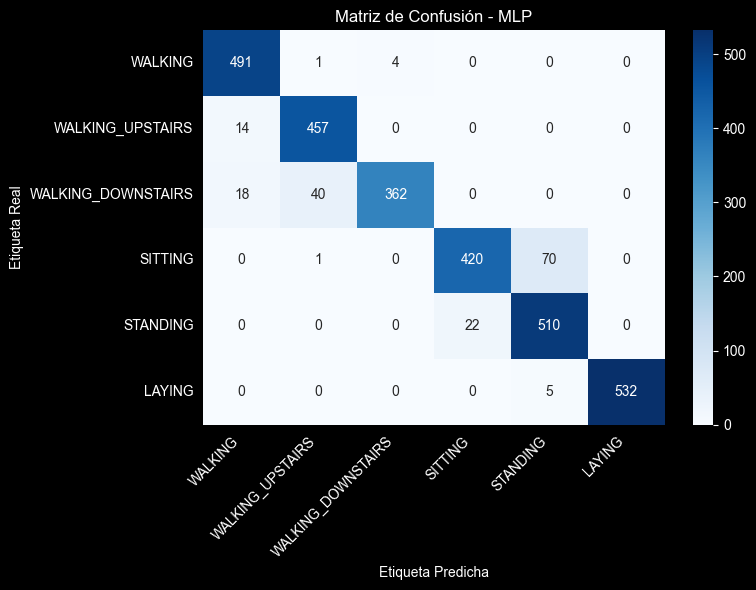

In [7]:
# Matriz de confusión
cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - MLP')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/cm_mlp.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Análisis de resultados

La matriz de confusión muestra cómo el modelo clasifica cada actividad. Los errores más comunes suelen ocurrir entre actividades similares como SITTING y STANDING, ya que sus señales de sensores pueden ser parecidas.

In [8]:
# Guardamos las métricas para el notebook de comparación
from sklearn.metrics import precision_score, recall_score, f1_score

metricas_mlp = {
    'modelo': 'MLP',
    'accuracy': accuracy_score(y_test_int, y_pred_int),
    'precision': precision_score(y_test_int, y_pred_int, average='weighted'),
    'recall': recall_score(y_test_int, y_pred_int, average='weighted'),
    'f1': f1_score(y_test_int, y_pred_int, average='weighted'),
    'tiempo_entrenamiento': tiempo_entrenamiento
}

print('Métricas del MLP:')
for k, v in metricas_mlp.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

import json
os.makedirs('../models', exist_ok=True)
with open('../models/metricas_mlp.json', 'w') as f:
    json.dump(metricas_mlp, f)
print('\nMétricas guardadas.')

Métricas del MLP:
  modelo: MLP
  accuracy: 0.9406
  precision: 0.9433
  recall: 0.9406
  f1: 0.9403
  tiempo_entrenamiento: 26.5039

Métricas guardadas.


In [9]:
# Guardar modelo
modelo_mlp.save('../models/modelo_mlp.keras')
print('Modelo MLP guardado.')

Modelo MLP guardado.


## 8. Caso de prueba individual

In [10]:
# Seleccionamos 5 muestras aleatorias para inspección
indices_muestra = np.random.choice(len(X_test), 5, replace=False)

print('Casos de prueba individuales:')
print(f'{"Índice":<8} {"Real":<25} {"Predicho":<25} {"Correcto"}')
print('-' * 70)
for idx in indices_muestra:
    real = nombres_clases[y_test_int[idx]]
    pred = nombres_clases[y_pred_int[idx]]
    correcto = '✓' if real == pred else '✗'
    print(f'{idx:<8} {real:<25} {pred:<25} {correcto}')

Casos de prueba individuales:
Índice   Real                      Predicho                  Correcto
----------------------------------------------------------------------
565      WALKING                   WALKING                   ✓
1220     STANDING                  STANDING                  ✓
1677     WALKING_UPSTAIRS          WALKING_UPSTAIRS          ✓
1577     LAYING                    LAYING                    ✓
2834     LAYING                    LAYING                    ✓


## Conclusiones del modelo MLP

**Ventajas del MLP para este problema:**
- Fácil de implementar y entender.
- Buen desempeño cuando las características ya están extraídas (datos tabulares).
- Entrenamiento rápido.

**Limitaciones:**
- No puede capturar dependencias temporales en las señales.
- Requiere que las características estén pre-calculadas; no trabaja bien con señales brutas.
- La información del orden temporal se pierde, ya que trata cada muestra como un vector independiente.

El MLP sirve como línea base. Se espera que los modelos diseñados específicamente para datos secuenciales (RNN, LSTM, GRU, Transformer) superen este resultado cuando trabajen con las señales crudas.